# 😊 Klasifikasi Emosi Wajah dengan GLCM + Logistic Regression

---

**Dataset:** Subset FER2013 (48×48 pixel, grayscale)  
**Metode Ekstraksi Fitur:** Gray-Level Co-occurrence Matrix (GLCM)  
**Model Klasifikasi:** Logistic Regression  
**Kelas Emosi:** Angry, Happy, Sad, Surprise

---

## Gambaran Umum Alur Kerja

```
Dataset (Folder)  →  Load & Preprocessing  →  Ekstraksi Fitur GLCM  →  Training Model  →  Evaluasi
```

Notebook ini dirancang agar mudah dipahami oleh pemula. Setiap bagian dilengkapi penjelasan tentang:
- **Library apa** yang digunakan dan **mengapa** library tersebut dipilih
- **Sintaks penting** yang dibedah agar tidak sekadar copy-paste
- **Visualisasi** di setiap tahap untuk memperkuat pemahaman intuitif

---
# BAGIAN 0 — Setup & Import Library Global

## Library yang Digunakan dan Alasannya

| Library | Peran dalam Proyek Ini |
|---|---|
| `os`, `glob` | Navigasi sistem file untuk memuat gambar dari subfolder secara otomatis |
| `numpy` | Operasi numerik pada array pixel gambar (fundamental untuk semua komputasi) |
| `matplotlib` | Membuat semua visualisasi: grid gambar, heatmap, bar chart, scatter plot |
| `seaborn` | Mempercantik visualisasi, terutama untuk confusion matrix dan heatmap |
| `Pillow (PIL)` | Membuka file gambar dari disk dan mengubah mode warnanya (RGB → Grayscale) |
| `scikit-image` | Fungsi inti ekstraksi fitur GLCM (`graycomatrix`, `graycoprops`) |
| `scikit-learn` | Logistic Regression, StandardScaler, PCA, t-SNE, dan semua metrik evaluasi |
| `warnings` | Menyembunyikan pesan peringatan yang tidak relevan agar output lebih bersih |

> **💡 Catatan Versi:** Pada scikit-learn ≥ 1.5, parameter `multi_class` di `LogisticRegression` sudah **dihapus**. Secara default, model sudah otomatis menangani klasifikasi multi-kelas menggunakan strategi One-vs-Rest (OvR) atau Multinomial tergantung solver yang dipilih. Kita cukup menulis `LogisticRegression(max_iter=1000)`.

In [1]:
# ============================================================
#  CELL 0 — Import Semua Library yang Dibutuhkan
# ============================================================

import os
import glob
import warnings
warnings.filterwarnings('ignore')   # Sembunyikan pesan warning agar output bersih

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from PIL import Image                  # Membuka dan memanipulasi file gambar

# scikit-image: fungsi GLCM
from skimage.feature import graycomatrix, graycoprops

# scikit-learn: model, preprocessing, evaluasi, reduksi dimensi
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Konfigurasi tampilan plot
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Seed untuk reproducibility (agar hasil eksperimen konsisten)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


---
# BAGIAN 1 — Persiapan & Preprocessing Citra

## 1.1 Konfigurasi Path Dataset

Pertama, kita definisikan **konstanta** (nilai tetap yang digunakan di seluruh notebook) dalam satu sel khusus. Praktik ini penting karena:
- Memudahkan perubahan konfigurasi tanpa mencari-cari di seluruh kode
- Mengurangi risiko inkonsistensi (typo nama folder, dll.)

### Library yang Digunakan:
- **`os`**: Modul bawaan Python untuk berinteraksi dengan sistem operasi. Fungsi `os.path.join()` digunakan untuk menggabungkan path folder agar benar di semua OS (Windows, Linux, Mac).

In [2]:
# ============================================================
#  CELL 1.1 — Konfigurasi Global
# ============================================================

# --- PATH DATASET ---
# Sesuaikan path ini dengan lokasi folder dataset di komputer Anda
BASE_DIR   = 'dataset'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

# --- KELAS EMOSI ---
# Urutan kelas ini akan konsisten digunakan di seluruh kode
CLASSES = ['angry', 'happy', 'sad', 'surprise']

# --- PARAMETER GAMBAR ---
IMG_SIZE = (48, 48)   # Target ukuran gambar setelah resize

# --- PARAMETER GLCM ---
DISTANCES = [1]                                 # Jarak piksel yang dihitung ko-kemunculannya
ANGLES    = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0°, 45°, 90°, 135° (dalam radian)
LEVELS_TO_TEST = [8, 16, 32]                    # Skenario kuantisasi yang akan diuji
GLCM_PROPS = ['contrast', 'homogeneity',        # Properti statistik yang akan diekstrak
              'energy', 'correlation']

# Verifikasi bahwa folder dataset ditemukan
for folder in [TRAIN_DIR, TEST_DIR]:
    status = "✅ DITEMUKAN" if os.path.exists(folder) else "❌ TIDAK DITEMUKAN — Periksa path!"
    print(f"  {folder}: {status}")

  dataset\train: ✅ DITEMUKAN
  dataset\test: ✅ DITEMUKAN


## 1.2 Fungsi Pemuatan & Preprocessing Gambar

Kita buat sebuah **fungsi** untuk memuat semua gambar dari dataset. Alasan menggunakan fungsi (bukan kode langsung):
- Bisa dipanggil dua kali: sekali untuk data train, sekali untuk data test
- Mudah dimodifikasi jika ada perubahan logika preprocessing

### Tahap Preprocessing yang Dilakukan:

1. **Baca gambar** dari disk menggunakan `PIL.Image.open()`
2. **Konversi ke Grayscale** dengan `.convert('L')`
   - `'L'` adalah kode mode PIL untuk grayscale (Luminance)
   - GLCM bekerja pada gambar 2D (satu channel), bukan 3-channel RGB
3. **Resize** ke `48×48` menggunakan `Image.LANCZOS` (filter interpolasi berkualitas tinggi)
4. **Normalisasi** nilai pixel dari rentang `[0, 255]` menjadi `[0.0, 1.0]`  
   - Formula: `pixel_baru = pixel_asli / 255.0`
   - Tujuan: mencegah fitur dengan skala besar mendominasi model

### Library yang Digunakan:
- **`PIL (Pillow)`**: Library Python yang paling umum untuk manipulasi gambar. Mendukung >30 format file gambar.
- **`numpy`**: Konversi objek PIL Image menjadi array NumPy (`np.array()`) agar bisa diproses secara numerik.

In [3]:
# ============================================================
#  CELL 1.2 — Fungsi Pemuatan & Preprocessing Dataset
# ============================================================

def load_dataset(data_dir, img_size=IMG_SIZE, classes=CLASSES):
    """
    Memuat gambar dari struktur folder berlabel dan melakukan preprocessing.

    Args:
        data_dir (str): Path ke folder utama (train atau test).
        img_size (tuple): Target ukuran gambar (width, height).
        classes (list): Daftar nama subfolder/kelas yang akan dimuat.

    Returns:
        images_raw  (list): Gambar asli uint8 [0-255] untuk visualisasi.
        images_norm (list): Gambar ternormalisasi float32 [0-1] untuk GLCM.
        labels      (list): Label kelas string untuk setiap gambar.
    """
    images_raw  = []   # Gambar asli (sebelum normalisasi) — untuk visualisasi
    images_norm = []   # Gambar ternormalisasi — untuk ekstraksi fitur
    labels      = []   # Label kelas

    for cls in classes:
        folder_path = os.path.join(data_dir, cls)

        # Cari semua file gambar (jpg dan png) di dalam subfolder kelas
        # glob.glob() mengembalikan list path file yang cocok dengan pola
        img_paths = glob.glob(os.path.join(folder_path, '*.jpg')) + \
                    glob.glob(os.path.join(folder_path, '*.png'))

        print(f"  Kelas '{cls}': {len(img_paths)} gambar ditemukan")

        for img_path in img_paths:
            try:
                # Step 1: Buka gambar dengan PIL
                img = Image.open(img_path)

                # Step 2: Konversi ke grayscale
                # .convert('L') → L = Luminance, menghasilkan 1 channel (2D array)
                img = img.convert('L')

                # Step 3: Resize gambar ke ukuran target
                # Image.LANCZOS = filter interpolasi berkualitas tinggi
                img = img.resize(img_size, Image.LANCZOS)

                # Step 4: Konversi PIL Image → NumPy array
                img_array = np.array(img, dtype=np.uint8)  # uint8: integer 0-255
                images_raw.append(img_array)               # Simpan versi asli

                # Step 5: Normalisasi pixel ke rentang [0.0, 1.0]
                img_norm = img_array.astype(np.float32) / 255.0
                images_norm.append(img_norm)

                labels.append(cls)

            except Exception as e:
                # Lewati gambar yang rusak/tidak bisa dibaca
                print(f"    ⚠️  Gagal memuat {img_path}: {e}")

    return images_raw, images_norm, labels


# --- Muat Data Train ---
print("📂 Memuat data TRAINING...")
train_raw, train_norm, train_labels = load_dataset(TRAIN_DIR)
print(f"   Total: {len(train_labels)} gambar\n")

# --- Muat Data Test ---
print("📂 Memuat data TEST...")
test_raw, test_norm, test_labels = load_dataset(TEST_DIR)
print(f"   Total: {len(test_labels)} gambar\n")

# --- Ringkasan Distribusi Kelas ---
print("📊 Distribusi Kelas (Training):")
for cls in CLASSES:
    count = train_labels.count(cls)
    bar   = '█' * (count // 50)   # Bar proporsional (1 blok = 50 gambar)
    print(f"   {cls:>10}: {count:5d} {bar}")

📂 Memuat data TRAINING...
  Kelas 'angry': 3100 gambar ditemukan
  Kelas 'happy': 3100 gambar ditemukan
  Kelas 'sad': 3100 gambar ditemukan
  Kelas 'surprise': 3100 gambar ditemukan
   Total: 12400 gambar

📂 Memuat data TEST...
  Kelas 'angry': 775 gambar ditemukan
  Kelas 'happy': 775 gambar ditemukan
  Kelas 'sad': 775 gambar ditemukan
  Kelas 'surprise': 775 gambar ditemukan
   Total: 3100 gambar

📊 Distribusi Kelas (Training):
        angry:  3100 ██████████████████████████████████████████████████████████████
        happy:  3100 ██████████████████████████████████████████████████████████████
          sad:  3100 ██████████████████████████████████████████████████████████████
     surprise:  3100 ██████████████████████████████████████████████████████████████


## 1.3 Visualisasi Before vs. After Preprocessing

Visualisasi ini penting untuk **memverifikasi** bahwa preprocessing berjalan benar. Kita akan menampilkan:
- **Kolom kiri (Before)**: Gambar asli dengan nilai pixel 0–255
- **Kolom kanan (After)**: Gambar yang sama setelah normalisasi, dilengkapi *colorbar* untuk melihat rentang nilai pixel baru (0.0–1.0)

### Sintaks Penting — `plt.colorbar()`:
```python
im = ax.imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
plt.colorbar(im, ax=ax)
```
- `ax.imshow()` mengembalikan objek `AxesImage` (kita simpan sebagai `im`)
- `plt.colorbar(im, ax=ax)` menggambar bar warna yang terhubung ke gambar tersebut
- `vmin` dan `vmax` memaksa skala warna ke rentang yang kita inginkan

### Sintaks Penting — `matplotlib.gridspec`:
```python
fig = plt.figure(figsize=(10, 20))
gs  = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.5)
ax  = fig.add_subplot(gs[row, col])
```
`GridSpec` memberi kontrol lebih presisi atas tata letak subplot dibandingkan `plt.subplots()`.

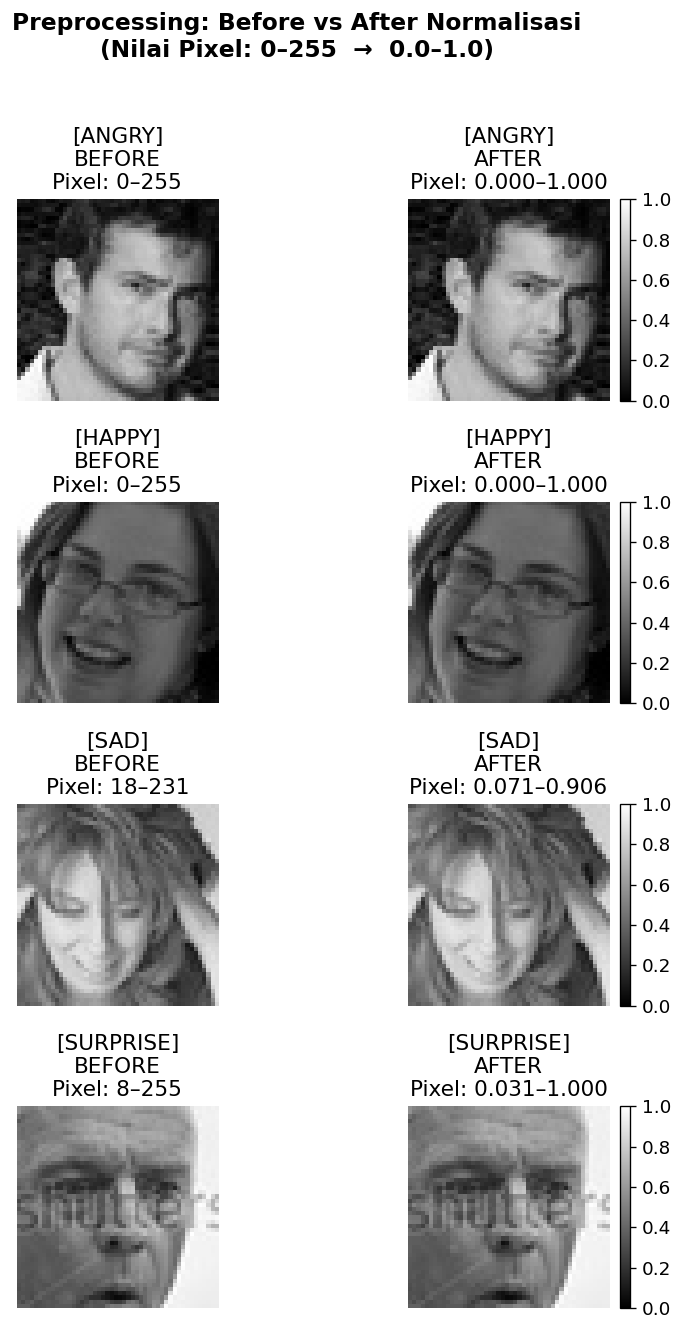


✅ Visualisasi disimpan sebagai '01_before_after_preprocessing.png'


In [4]:
# ============================================================
#  CELL 1.3 — Visualisasi Before vs After Preprocessing
# ============================================================

def get_one_sample_per_class(raw_list, norm_list, label_list, classes=CLASSES):
    """Mengambil 1 gambar contoh untuk setiap kelas."""
    samples = {}
    for cls in classes:
        idx = label_list.index(cls)   # Cari indeks pertama dari kelas ini
        samples[cls] = {
            'raw' : raw_list[idx],
            'norm': norm_list[idx]
        }
    return samples

samples = get_one_sample_per_class(train_raw, train_norm, train_labels)

# --- Buat Grid Visualisasi ---
# Layout: 4 baris (satu per kelas) × 2 kolom (Before & After)
n_classes = len(CLASSES)
fig, axes = plt.subplots(
    nrows=n_classes, ncols=2,
    figsize=(7, n_classes * 3),
    gridspec_kw={'wspace': 0.4, 'hspace': 0.5}
)

fig.suptitle('Preprocessing: Before vs After Normalisasi\n(Nilai Pixel: 0–255  →  0.0–1.0)',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASSES):
    img_raw  = samples[cls]['raw']
    img_norm = samples[cls]['norm']

    # --- Kolom 0: BEFORE (gambar asli uint8) ---
    ax_before = axes[row_idx, 0]
    ax_before.imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    ax_before.set_title(f'[{cls.upper()}]\nBEFORE\nPixel: {img_raw.min()}–{img_raw.max()}')
    ax_before.axis('off')   # Sembunyikan sumbu x/y

    # --- Kolom 1: AFTER (gambar ternormalisasi float32) ---
    ax_after = axes[row_idx, 1]
    # imshow() mengembalikan objek AxesImage yang kita simpan sebagai 'im'
    im = ax_after.imshow(img_norm, cmap='gray', vmin=0.0, vmax=1.0)
    ax_after.set_title(
        f'[{cls.upper()}]\nAFTER\nPixel: {img_norm.min():.3f}–{img_norm.max():.3f}'
    )
    ax_after.axis('off')

    # Tambahkan colorbar — menunjukkan pemetaan warna ke nilai pixel
    # fraction & pad: mengatur ukuran dan jarak colorbar dari gambar
    plt.colorbar(im, ax=ax_after, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('01_before_after_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Visualisasi disimpan sebagai '01_before_after_preprocessing.png'")

---
# BAGIAN 2 — Representasi Fitur: GLCM

## 2.1 Konsep GLCM (Gray-Level Co-occurrence Matrix)

**GLCM** (Gray-Level Co-occurrence Matrix) adalah metode analisis tekstur yang mengukur **seberapa sering dua nilai pixel tertentu muncul bersebelahan** dalam gambar, pada jarak dan arah tertentu.

### Ilustrasi Sederhana:
Bayangkan gambar 4×4 dengan 4 level abu-abu (0, 1, 2, 3):  
Jika pixel bernilai `1` sering bersebelahan dengan pixel bernilai `2` (ke kanan, sudut 0°),  
maka `GLCM[1, 2]` akan bernilai tinggi.

### Properti Statistik yang Diekstrak dari GLCM:

| Properti | Makna Intuitif | Nilai Tinggi Berarti... |
|---|---|---|
| **Contrast** | Perbedaan intensitas antara piksel tetangga | Tekstur kasar, banyak tepi tajam |
| **Homogeneity** | Keseragaman nilai piksel di seluruh gambar | Tekstur halus, transisi gradual |
| **Energy** | Keseragaman distribusi ko-kemunculan | Pola tekstur yang berulang |
| **Correlation** | Ketergantungan linear antar piksel tetangga | Transisi nilai piksel yang teratur |

### Kuantisasi Level (Binning):
Sebelum membuat GLCM, nilai pixel ternormalisasi `[0.0, 1.0]` di-bin ulang ke `L` level diskrit:  
- `L=8`: pixel dikelompokkan ke 8 "keranjang" → matriks berukuran 8×8  
- `L=16`: 16 keranjang → matriks 16×16  
- `L=32`: 32 keranjang → matriks 32×32  

> **Trade-off**: L besar → detail lebih banyak, tapi sensitif terhadap noise dan komputasi lebih berat. L kecil → lebih robust terhadap noise, tapi kehilangan nuansa.

## 2.2 Bedah Sintaks: `graycomatrix()` dan `graycoprops()`

```python
glcm = graycomatrix(
    image,          # Array 2D integer (gambar yang sudah dikuantisasi)
    distances=[1],  # Jarak piksel: [1] = piksel yang langsung bersebelahan
    angles=[0],     # Sudut arah: 0=kanan, π/4=diagonal kanan-bawah, π/2=bawah, 3π/4=diagonal kiri-bawah
    levels=16,      # Jumlah level abu-abu (L)
    symmetric=True, # Jika True: hitung juga arah sebaliknya → matriks simetris
    normed=True     # Jika True: bagi dengan jumlah pasangan → nilai probabilitas [0,1]
)
# Output shape: (levels, levels, len(distances), len(angles))
# Contoh: levels=16, distances=[1], angles=[0°,45°,90°,135°] → shape (16, 16, 1, 4)

prop_value = graycoprops(glcm, prop='contrast')
# Output shape: (len(distances), len(angles))
# Contoh: (1, 4) → nilai contrast untuk setiap kombinasi jarak×sudut
```

### Library yang Digunakan:
- **`skimage.feature`** (dari scikit-image): Berisi fungsi-fungsi ekstrasi fitur gambar tingkat tinggi. `graycomatrix` efisien karena diimplementasikan di level C (bukan Python murni).

In [5]:
# ============================================================
#  CELL 2.1 — Fungsi Inti Ekstraksi Fitur GLCM
# ============================================================

def quantize_image(img_norm, levels):
    """
    Mengkuantisasi gambar ternormalisasi [0,1] ke L level integer diskrit [0, levels-1].

    Contoh: levels=8, pixel 0.75 → 0.75 * 8 = 6.0 → bin ke-6

    Args:
        img_norm (np.ndarray): Gambar grayscale float32, nilai [0.0, 1.0].
        levels (int): Jumlah level kuantisasi (8, 16, atau 32).

    Returns:
        np.ndarray: Gambar integer dengan nilai [0, levels-1].
    """
    # np.clip: pastikan tidak ada nilai tepat 1.0 yang menghasilkan index = levels
    img_quantized = np.clip(
        np.floor(img_norm * levels).astype(np.int32),
        0, levels - 1
    )
    return img_quantized


def extract_glcm_features(img_norm, levels, distances=DISTANCES, angles=ANGLES,
                           props=GLCM_PROPS, aggregation='mean'):
    """
    Mengekstrak fitur statistik dari GLCM sebuah gambar.

    Args:
        img_norm    (np.ndarray): Gambar grayscale ternormalisasi [0,1].
        levels      (int)       : Jumlah level kuantisasi GLCM.
        distances   (list)      : List jarak piksel, contoh [1].
        angles      (list)      : List sudut dalam radian, contoh [0, π/4, π/2, 3π/4].
        props       (list)      : Properti GLCM yang diekstrak.
        aggregation (str)       : 'mean' → rata-rata antar sudut;
                                  'concat' → gabungkan semua nilai (4 sudut × 4 properti).

    Returns:
        np.ndarray: Vektor fitur 1D.
            - 'mean'  : panjang = len(props)           = 4 dimensi
            - 'concat': panjang = len(props)*len(angles)= 16 dimensi
    """
    # Langkah 1: Kuantisasi gambar ke L level
    img_q = quantize_image(img_norm, levels)

    # Langkah 2: Hitung matriks GLCM
    # Output shape: (levels, levels, len(distances), len(angles))
    glcm = graycomatrix(
        img_q,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,   # Simetriskan matriks (hitung dua arah)
        normed=True       # Normalisasi → nilai probabilitas ko-kemunculan
    )

    # Langkah 3: Ekstrak properti statistik dari GLCM
    feature_vector = []

    if aggregation == 'mean':
        # Rata-rata nilai properti di semua sudut
        # graycoprops mengembalikan shape (len(distances), len(angles))
        # .mean() → scalar tunggal untuk setiap properti
        for prop in props:
            value = graycoprops(glcm, prop).mean()
            feature_vector.append(value)

    elif aggregation == 'concat':
        # Gabungkan (flatten) nilai untuk setiap sudut secara terpisah
        # Hasil: 4 properti × 4 sudut = 16 nilai
        for prop in props:
            values = graycoprops(glcm, prop).flatten()  # Shape (1,4) → (4,)
            feature_vector.extend(values)

    return np.array(feature_vector, dtype=np.float32)


# --- Test cepat pada satu gambar ---
test_img  = train_norm[0]
feat_mean = extract_glcm_features(test_img, levels=16, aggregation='mean')
feat_conc = extract_glcm_features(test_img, levels=16, aggregation='concat')

print("🧪 Test Ekstraksi Fitur GLCM (Level=16):")
print(f"   Agregasi 'mean'  → shape: {feat_mean.shape} | nilai: {np.round(feat_mean, 4)}")
print(f"   Agregasi 'concat'→ shape: {feat_conc.shape} | nilai: {np.round(feat_conc, 4)}")

🧪 Test Ekstraksi Fitur GLCM (Level=16):
   Agregasi 'mean'  → shape: (4,) | nilai: [3.1831 0.6025 0.1629 0.9145]
   Agregasi 'concat'→ shape: (16,) | nilai: [2.7566 4.2345 2.09   3.6514 0.6356 0.5702 0.6405 0.5638 0.1706 0.1553
 0.1707 0.1549 0.9263 0.886  0.9442 0.9017]


## 2.3 Visualisasi Heatmap Matriks GLCM

Kita akan memvisualisasikan matriks GLCM mentah dalam bentuk **heatmap** untuk satu gambar contoh. Ini membantu memahami secara intuitif apa yang sebenarnya direpresentasikan GLCM.

### Membaca Heatmap GLCM:
- **Sumbu X & Y**: Nilai level abu-abu (0 sampai L-1)
- **Nilai di sel (i, j)**: Probabilitas (atau frekuensi) pixel bernilai `i` bersebelahan dengan pixel bernilai `j`
- **Pola diagonal**: Wajah yang seragam (banyak area homogen) akan menghasilkan nilai tinggi di sepanjang diagonal utama
- **Pola off-diagonal**: Menunjukkan transisi pixel yang dramatis (tepi, garis)

### Sintaks Penting — `sns.heatmap()`:
```python
sns.heatmap(
    data,           # Array 2D yang akan divisualisasikan
    annot=True,     # Tampilkan nilai angka di setiap sel
    fmt='.3f',      # Format angka: 3 desimal
    cmap='YlOrRd',  # Skema warna: kuning → oranye → merah
    xticklabels=n,  # Tampilkan label setiap n kolom (agar tidak padat)
    yticklabels=n
)
```

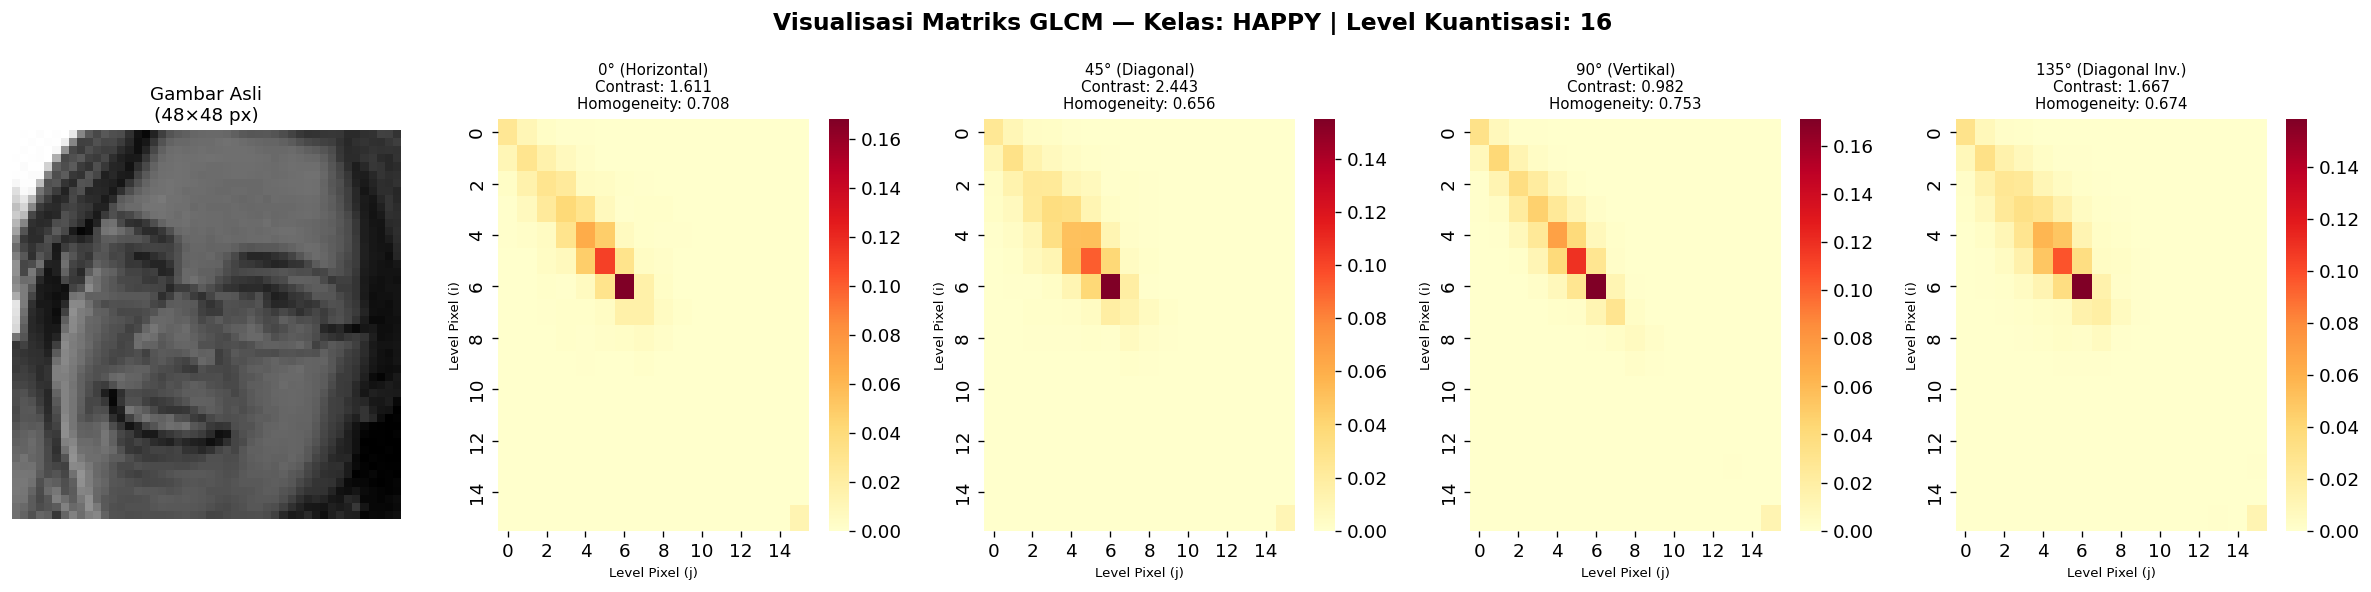

✅ Heatmap GLCM disimpan sebagai '02_glcm_heatmap.png'


In [6]:
# ============================================================
#  CELL 2.2 — Visualisasi Heatmap Matriks GLCM
# ============================================================

# Ambil satu gambar contoh dari kelas 'happy'
idx_happy = train_labels.index('happy')
example_img_norm = train_norm[idx_happy]
example_img_raw  = train_raw[idx_happy]

LEVELS_VIS = 16   # Level untuk visualisasi

# --- Hitung GLCM mentah untuk semua sudut ---
example_img_q = quantize_image(example_img_norm, LEVELS_VIS)
glcm_full = graycomatrix(
    example_img_q,
    distances=[1],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=LEVELS_VIS,
    symmetric=True,
    normed=True
)
# glcm_full.shape → (16, 16, 1, 4): 16 level × 16 level × 1 jarak × 4 sudut

angle_labels = ['0° (Horizontal)', '45° (Diagonal)', '90° (Vertikal)', '135° (Diagonal Inv.)']

# --- Buat figure dengan 5 subplot: gambar asli + 4 heatmap sudut ---
fig = plt.figure(figsize=(20, 5))
fig.suptitle(
    f'Visualisasi Matriks GLCM — Kelas: HAPPY | Level Kuantisasi: {LEVELS_VIS}',
    fontsize=14, fontweight='bold'
)

# Panel kiri: gambar asli
ax0 = fig.add_subplot(1, 5, 1)
ax0.imshow(example_img_raw, cmap='gray')
ax0.set_title('Gambar Asli\n(48×48 px)', fontsize=11)
ax0.axis('off')

# 4 panel heatmap, satu per sudut
for angle_idx in range(4):
    ax = fig.add_subplot(1, 5, angle_idx + 2)

    # Ambil matriks GLCM untuk sudut ini
    # glcm_full[:, :, 0, angle_idx] → irisan 2D untuk distance[0] dan angle[angle_idx]
    glcm_2d = glcm_full[:, :, 0, angle_idx]

    # Heatmap menggunakan seaborn
    # annot=True → tampilkan nilai di sel (tidak cocok untuk matrix besar)
    # fmt='.2f'  → 2 angka di belakang desimal
    # xticklabels & yticklabels=2 → label setiap 2 kolom/baris agar tidak padat
    sns.heatmap(
        glcm_2d,
        ax=ax,
        cmap='YlOrRd',
        xticklabels=2,
        yticklabels=2,
        cbar=True,
        linewidths=0
    )

    # Ekstrak nilai properti statistik untuk sudut ini
    contrast_val    = graycoprops(glcm_full, 'contrast')[0, angle_idx]
    homogeneity_val = graycoprops(glcm_full, 'homogeneity')[0, angle_idx]

    ax.set_title(
        f'{angle_labels[angle_idx]}\n'
        f'Contrast: {contrast_val:.3f}\n'
        f'Homogeneity: {homogeneity_val:.3f}',
        fontsize=9
    )
    ax.set_xlabel('Level Pixel (j)', fontsize=8)
    ax.set_ylabel('Level Pixel (i)', fontsize=8)

plt.tight_layout()
plt.savefig('02_glcm_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Heatmap GLCM disimpan sebagai '02_glcm_heatmap.png'")

## 2.4 Visualisasi Perbandingan Fitur Antar Kelas (Bar Chart)

Setelah memahami bentuk matriks GLCM, kita visualisasikan **nilai fitur yang sudah diekstrak** untuk membandingkan perbedaan karakteristik tekstur antara ke-4 kelas emosi.

### Yang Diharapkan Terlihat:
- Emosi **Happy** → wajah cenderung homogen di area pipi dan dahi → Homogeneity tinggi
- Emosi **Angry** → banyak kerutan dan lekukan tajam → Contrast tinggi
- Perbedaan antar kelas di fitur tertentu mengindikasikan fitur tersebut **diskriminatif** (berguna untuk klasifikasi)

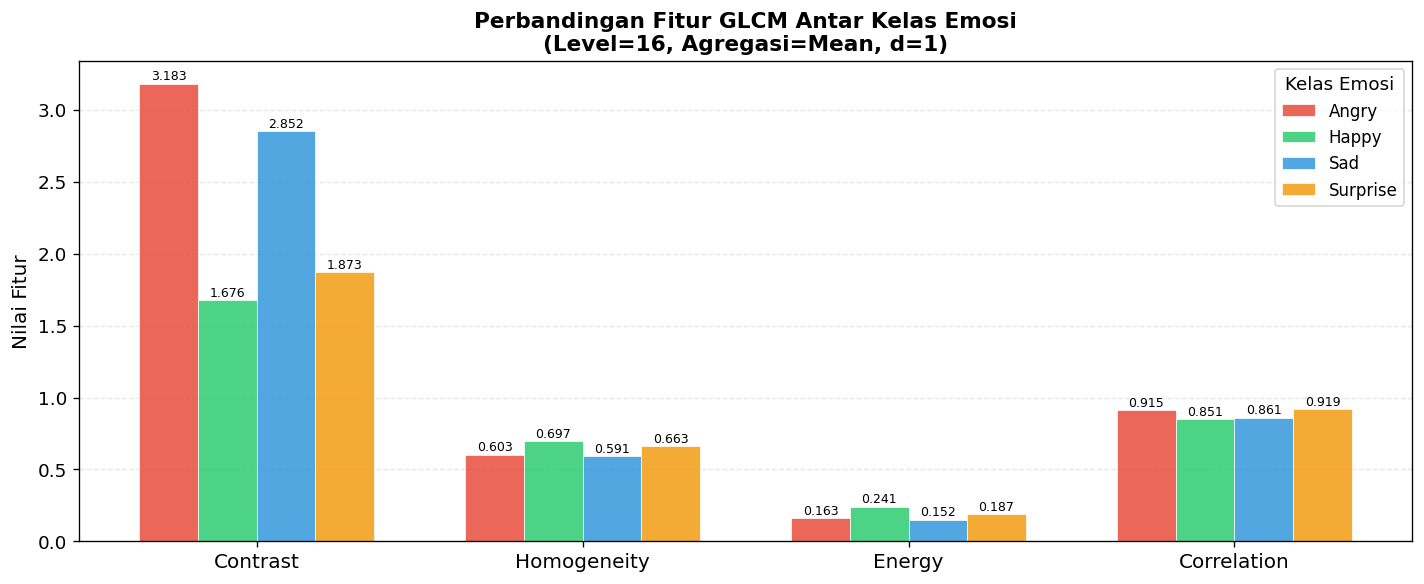

✅ Bar chart fitur GLCM disimpan sebagai '03_glcm_feature_comparison.png'


In [7]:
# ============================================================
#  CELL 2.3 — Bar Chart Perbandingan Fitur GLCM Antar Kelas
# ============================================================

# Ekstrak fitur untuk satu gambar dari setiap kelas (mode 'mean', level=16)
class_features = {}
for cls in CLASSES:
    idx = train_labels.index(cls)
    feat = extract_glcm_features(train_norm[idx], levels=16, aggregation='mean')
    class_features[cls] = feat

# --- Bar Chart ---
n_props  = len(GLCM_PROPS)
x_pos    = np.arange(n_props)          # Posisi grup di sumbu X [0, 1, 2, 3]
bar_w    = 0.18                        # Lebar setiap bar
colors   = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']  # Merah, Hijau, Biru, Oranye

fig, ax = plt.subplots(figsize=(12, 5))

for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    # Offset posisi bar agar tidak menumpuk
    # i - (n_classes-1)/2 → pusatkan grup di sekitar x_pos
    offset  = (i - (len(CLASSES) - 1) / 2) * bar_w
    bars    = ax.bar(
        x_pos + offset,          # Posisi x dengan offset
        class_features[cls],     # Nilai fitur
        width=bar_w,
        label=cls.capitalize(),
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    # Tambahkan anotasi nilai di atas setiap bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

# Konfigurasi tampilan
ax.set_xticks(x_pos)
ax.set_xticklabels([p.capitalize() for p in GLCM_PROPS], fontsize=12)
ax.set_ylabel('Nilai Fitur', fontsize=12)
ax.set_title(
    'Perbandingan Fitur GLCM Antar Kelas Emosi\n(Level=16, Agregasi=Mean, d=1)',
    fontsize=13, fontweight='bold'
)
ax.legend(title='Kelas Emosi', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)   # Letakkan grid di belakang bar

plt.tight_layout()
plt.savefig('03_glcm_feature_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Bar chart fitur GLCM disimpan sebagai '03_glcm_feature_comparison.png'")

---
# BAGIAN 3 — Ekstraksi Fitur Massal & Pemodelan

## 3.1 Ekstraksi Fitur untuk Seluruh Dataset

Sekarang kita terapkan fungsi GLCM ke **semua gambar** dalam dataset. Kita siapkan fitur untuk semua kombinasi skenario:
- 3 level kuantisasi: 8, 16, 32
- 2 metode agregasi: mean, concat
- Total: **6 skenario eksperimen**

### Strategi Efisiensi:
Komputasi GLCM cukup intensif. Kita ekstrak semua skenario sekaligus dalam satu loop agar setiap gambar hanya dibaca sekali per level.

### Library yang Digunakan:
- **`sklearn.preprocessing.LabelEncoder`**: Mengubah label string (`'angry'`, `'happy'`, ...) menjadi integer (0, 1, 2, 3). Model scikit-learn membutuhkan label numerik.
- **`sklearn.preprocessing.StandardScaler`**: Menstandarisasi fitur agar memiliki mean=0 dan std=1. Ini **wajib** untuk Logistic Regression karena model ini sensitif terhadap skala fitur.

In [8]:
# ============================================================
#  CELL 3.1 — Ekstraksi Fitur Massal untuk Semua Skenario
# ============================================================

def extract_features_bulk(images_norm, labels, levels, aggregation):
    """
    Mengekstrak fitur GLCM untuk seluruh dataset.

    Returns:
        X (np.ndarray): Feature matrix, shape (n_samples, n_features)
        y (np.ndarray): Label array (encoded integer), shape (n_samples,)
    """
    X = []
    for img_norm in images_norm:
        feat = extract_glcm_features(img_norm, levels=levels, aggregation=aggregation)
        X.append(feat)
    return np.array(X, dtype=np.float32)


# --- Encode label string → integer ---
# LabelEncoder memetakan: angry=0, happy=1, sad=2, surprise=3 (diurutkan alfabet)
le = LabelEncoder()
y_train = le.fit_transform(train_labels)   # fit: belajar pemetaan, transform: terapkan
y_test  = le.transform(test_labels)        # Gunakan pemetaan YANG SAMA dari training

print("🔢 Pemetaan Label:")
for cls_name, cls_int in zip(le.classes_, le.transform(le.classes_)):
    print(f"   '{cls_name}' → {cls_int}")

# --- Ekstrak fitur untuk semua kombinasi skenario ---
# Simpan dalam dictionary: key = 'level-agregasi', value = (X_train, X_test)
scenarios = {}

for level in LEVELS_TO_TEST:
    for agg in ['mean', 'concat']:
        key = f"{level}-{agg}"
        print(f"\n⚙️  Mengekstrak fitur: Level={level}, Agregasi={agg}...", end=' ')

        X_train_raw = extract_features_bulk(train_norm, train_labels, level, agg)
        X_test_raw  = extract_features_bulk(test_norm,  test_labels,  level, agg)

        # --- Standarisasi Fitur ---
        # StandardScaler: z = (x - mean) / std
        # PENTING: fit HANYA pada data training, lalu transform keduanya
        # Alasan: mencegah data leakage (informasi test masuk ke proses training)
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)   # Belajar mean/std dari train
        X_test  = scaler.transform(X_test_raw)         # Terapkan ke test

        scenarios[key] = {
            'X_train': X_train,
            'X_test' : X_test,
            'scaler' : scaler,
            'n_feat' : X_train.shape[1]
        }

        print(f"✅  Shape: {X_train.shape}")

print("\n🎯 Semua fitur berhasil diekstrak!")

🔢 Pemetaan Label:
   'angry' → 0
   'happy' → 1
   'sad' → 2
   'surprise' → 3

⚙️  Mengekstrak fitur: Level=8, Agregasi=mean... ✅  Shape: (12400, 4)

⚙️  Mengekstrak fitur: Level=8, Agregasi=concat... ✅  Shape: (12400, 16)

⚙️  Mengekstrak fitur: Level=16, Agregasi=mean... ✅  Shape: (12400, 4)

⚙️  Mengekstrak fitur: Level=16, Agregasi=concat... ✅  Shape: (12400, 16)

⚙️  Mengekstrak fitur: Level=32, Agregasi=mean... ✅  Shape: (12400, 4)

⚙️  Mengekstrak fitur: Level=32, Agregasi=concat... ✅  Shape: (12400, 16)

🎯 Semua fitur berhasil diekstrak!


## 3.2 Training Model: Logistic Regression

### Mengapa Logistic Regression?
Logistic Regression adalah model klasifikasi linear yang sederhana dan **interpretabel**. Meskipun "sederhana", ia adalah baseline yang sangat kuat dan sering digunakan sebagai pembanding.

### Bedah Parameter `LogisticRegression()`:

```python
LogisticRegression(
    max_iter=1000,        # Jumlah iterasi maksimum untuk konvergensi optimasi
                          # Default (100) sering tidak cukup untuk data multikelas
                          # → naikkan ke 1000 agar model pasti konvergen

    solver='lbfgs',       # Algoritma optimasi (default: 'lbfgs')
                          # L-BFGS: cocok untuk dataset kecil-menengah, multi-class

    C=1.0,                # Invers dari kekuatan regularisasi (default: 1.0)
                          # C kecil → regularisasi kuat (model lebih sederhana)
                          # C besar → regularisasi lemah (model lebih kompleks)

    random_state=42       # Seed untuk reproducibility
)
```

> **Catatan scikit-learn ≥ 1.5:** Parameter `multi_class` telah **dihapus**. Model otomatis menggunakan strategi 'auto' yang setara dengan One-vs-Rest untuk solver 'lbfgs' pada kasus multi-class.

### Library yang Digunakan:
- **`sklearn.linear_model.LogisticRegression`**: Implementasi Logistic Regression yang sudah dioptimasi. Mendukung klasifikasi biner maupun multi-kelas secara otomatis.

In [9]:
# ============================================================
#  CELL 3.2 — Training Logistic Regression untuk Semua Skenario
# ============================================================

results = {}   # Menyimpan hasil untuk setiap skenario

print("🏋️  Melatih Logistic Regression untuk 6 skenario eksperimen...\n")
print(f"{'Skenario':<20} {'Dim Fitur':>10} {'Akurasi Train':>15} {'Akurasi Test':>14}")
print("-" * 62)

for key, data in scenarios.items():
    X_train = data['X_train']
    X_test  = data['X_test']

    # --- Inisialisasi dan latih model ---
    # max_iter=1000: cukup untuk konvergensi pada data ini
    # random_state: agar hasil dapat direproduksi
    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)   # Proses training

    # --- Prediksi dan evaluasi ---
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)

    results[key] = {
        'model'      : model,
        'y_pred_test': y_pred_test,
        'acc_train'  : acc_train,
        'acc_test'   : acc_test
    }

    print(f"{key:<20} {data['n_feat']:>10} {acc_train:>14.4f} {acc_test:>13.4f}")

# --- Temukan skenario terbaik berdasarkan akurasi test ---
best_key = max(results, key=lambda k: results[k]['acc_test'])
best_acc = results[best_key]['acc_test']

print("-" * 62)
print(f"\n🏆 Skenario Terbaik: '{best_key}' dengan Akurasi Test = {best_acc:.4f}")

🏋️  Melatih Logistic Regression untuk 6 skenario eksperimen...

Skenario              Dim Fitur   Akurasi Train   Akurasi Test
--------------------------------------------------------------
8-mean                        4         0.3219        0.3152
8-concat                     16         0.3687        0.3823
16-mean                       4         0.3143        0.3100
16-concat                    16         0.3652        0.3765
32-mean                       4         0.3142        0.3116
32-concat                    16         0.3603        0.3765
--------------------------------------------------------------

🏆 Skenario Terbaik: '8-concat' dengan Akurasi Test = 0.3823


---
# BAGIAN 4 — Evaluasi & Visualisasi Analisis

## 4.1 Classification Report — Model Terbaik

**Classification Report** adalah ringkasan performa model per kelas. Metrik yang dilaporkan:

| Metrik | Formula | Arti |
|---|---|---|
| **Precision** | TP / (TP+FP) | Dari semua yang diprediksi kelas X, berapa % yang benar? |
| **Recall** | TP / (TP+FN) | Dari semua yang sebenarnya kelas X, berapa % yang terdeteksi? |
| **F1-Score** | 2 × (P×R)/(P+R) | Rata-rata harmonik Precision dan Recall |
| **Support** | — | Jumlah sampel aktual di kelas tersebut |
| **Accuracy** | (TP+TN)/Total | Akurasi keseluruhan |

> **TP** = True Positive, **FP** = False Positive, **FN** = False Negative

In [10]:
# ============================================================
#  CELL 4.1 — Classification Report: Model Terbaik
# ============================================================

best_result    = results[best_key]
y_pred_best    = best_result['y_pred_test']
class_names    = [c.capitalize() for c in le.classes_]

print(f"{'='*60}")
print(f"  📊 CLASSIFICATION REPORT — Skenario: {best_key.upper()}")
print(f"{'='*60}")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=class_names
))

  📊 CLASSIFICATION REPORT — Skenario: 8-CONCAT
              precision    recall  f1-score   support

       Angry       0.36      0.20      0.25       775
       Happy       0.36      0.36      0.36       775
         Sad       0.36      0.40      0.38       775
    Surprise       0.43      0.57      0.49       775

    accuracy                           0.38      3100
   macro avg       0.38      0.38      0.37      3100
weighted avg       0.38      0.38      0.37      3100



## 4.2 Confusion Matrix (Analisis 1 & 2)

**Confusion Matrix** menunjukkan distribusi prediksi vs label sebenarnya dalam bentuk tabel.

### Cara Membaca Confusion Matrix:
```
Baris  = Label ASLI (Actual/True)
Kolom  = Label PREDIKSI (Predicted)

Diagonal utama (kiri-atas ke kanan-bawah) = Prediksi BENAR
Di luar diagonal                           = Prediksi SALAH
```

### Pertanyaan yang Dijawab Visualisasi Ini:
1. **Apakah GLCM cukup membedakan emosi?** → Lihat nilai di diagonal: semakin besar, semakin baik.
2. **Emosi mana yang paling sulit diprediksi?** → Kelas dengan nilai terbesar di luar diagonal adalah yang paling sering salah dikenali.

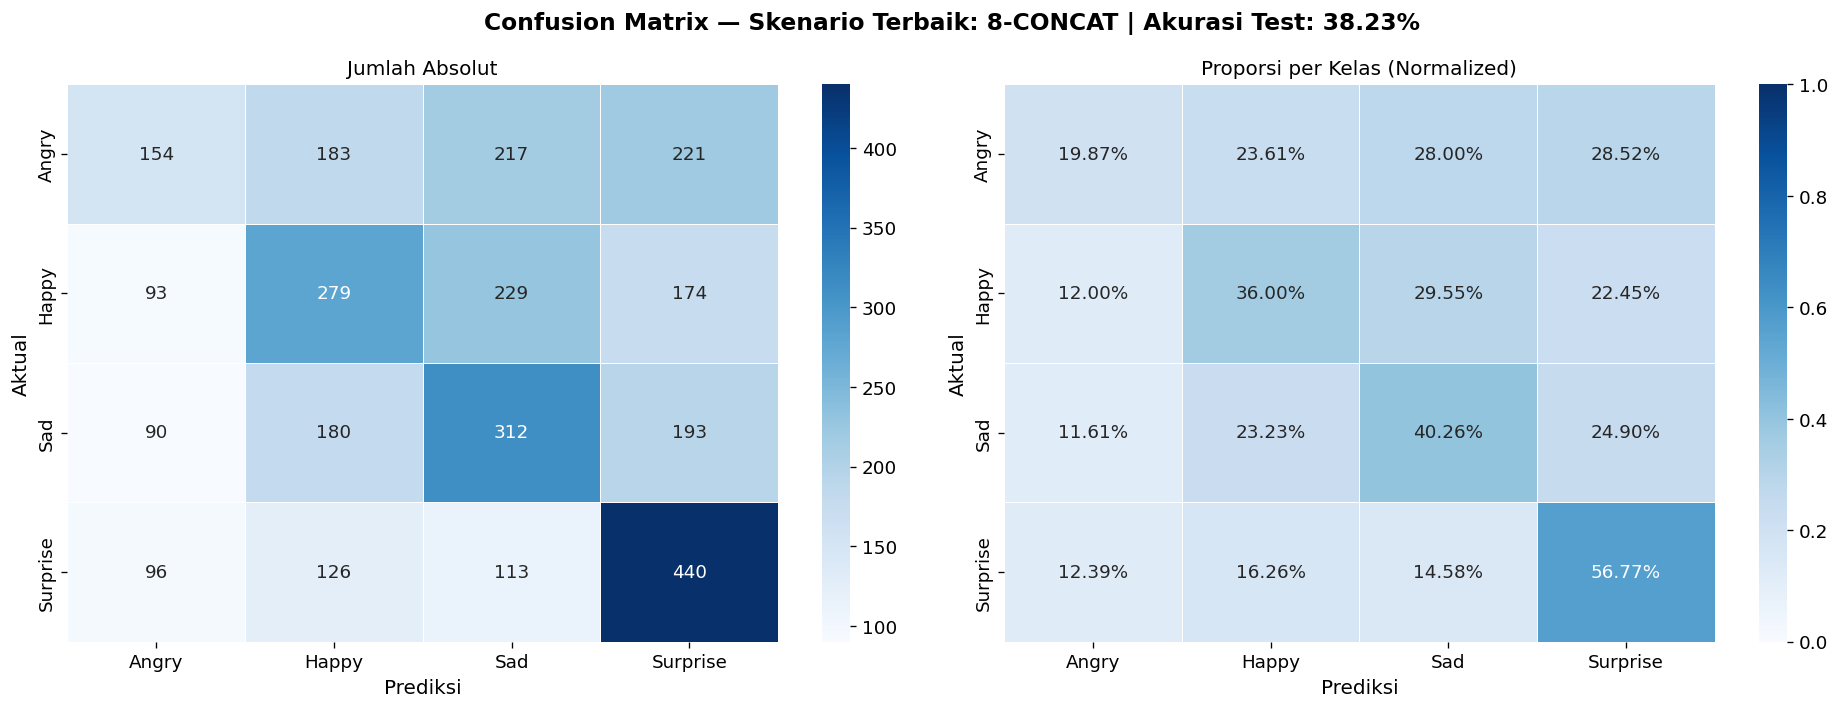

✅ Confusion matrix disimpan sebagai '04_confusion_matrix.png'


In [11]:
# ============================================================
#  CELL 4.2 — Confusion Matrix: Model Terbaik
# ============================================================

cm = confusion_matrix(y_test, y_pred_best)

# Hitung juga confusion matrix yang dinormalisasi (persentase per baris)
# Normalisasi per baris: cm[i,j] / sum(cm[i,:])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Confusion Matrix — Skenario Terbaik: {best_key.upper()} | '
    f'Akurasi Test: {best_acc:.2%}',
    fontsize=14, fontweight='bold'
)

# --- Panel kiri: Confusion Matrix (jumlah absolut) ---
sns.heatmap(
    cm,
    ax=axes[0],
    annot=True,              # Tampilkan angka di setiap sel
    fmt='d',                 # Format integer
    cmap='Blues',            # Skema warna biru
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white'
)
axes[0].set_title('Jumlah Absolut', fontsize=12)
axes[0].set_xlabel('Prediksi', fontsize=12)
axes[0].set_ylabel('Aktual', fontsize=12)

# --- Panel kanan: Confusion Matrix Ternormalisasi (proporsi per kelas) ---
sns.heatmap(
    cm_norm,
    ax=axes[1],
    annot=True,
    fmt='.2%',              # Format persentase dengan 2 desimal
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=1          # Skala tetap 0-100%
)
axes[1].set_title('Proporsi per Kelas (Normalized)', fontsize=12)
axes[1].set_xlabel('Prediksi', fontsize=12)
axes[1].set_ylabel('Aktual', fontsize=12)

plt.tight_layout()
plt.savefig('04_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Confusion matrix disimpan sebagai '04_confusion_matrix.png'")

## 4.3 Bar Chart Perbandingan Akurasi Semua Skenario (Analisis 3)

Visualisasi ini menjawab pertanyaan: **"Apa yang terjadi jika level kuantisasi GLCM diubah dari 8 → 16 → 32?"**

Kita bandingkan akurasi **test set** dari ke-6 skenario secara bersamaan, dikelompokkan berdasarkan:
- Level kuantisasi (sumbu X atau warna)
- Metode agregasi (Mean vs Concat)

### Yang Perlu Diperhatikan:
- Apakah level yang lebih tinggi **selalu** lebih baik?
- Apakah Concat (16 dimensi) **selalu** lebih baik dari Mean (4 dimensi)?
- Adakah **sweet spot** (titik optimal) di antara ketiga level?

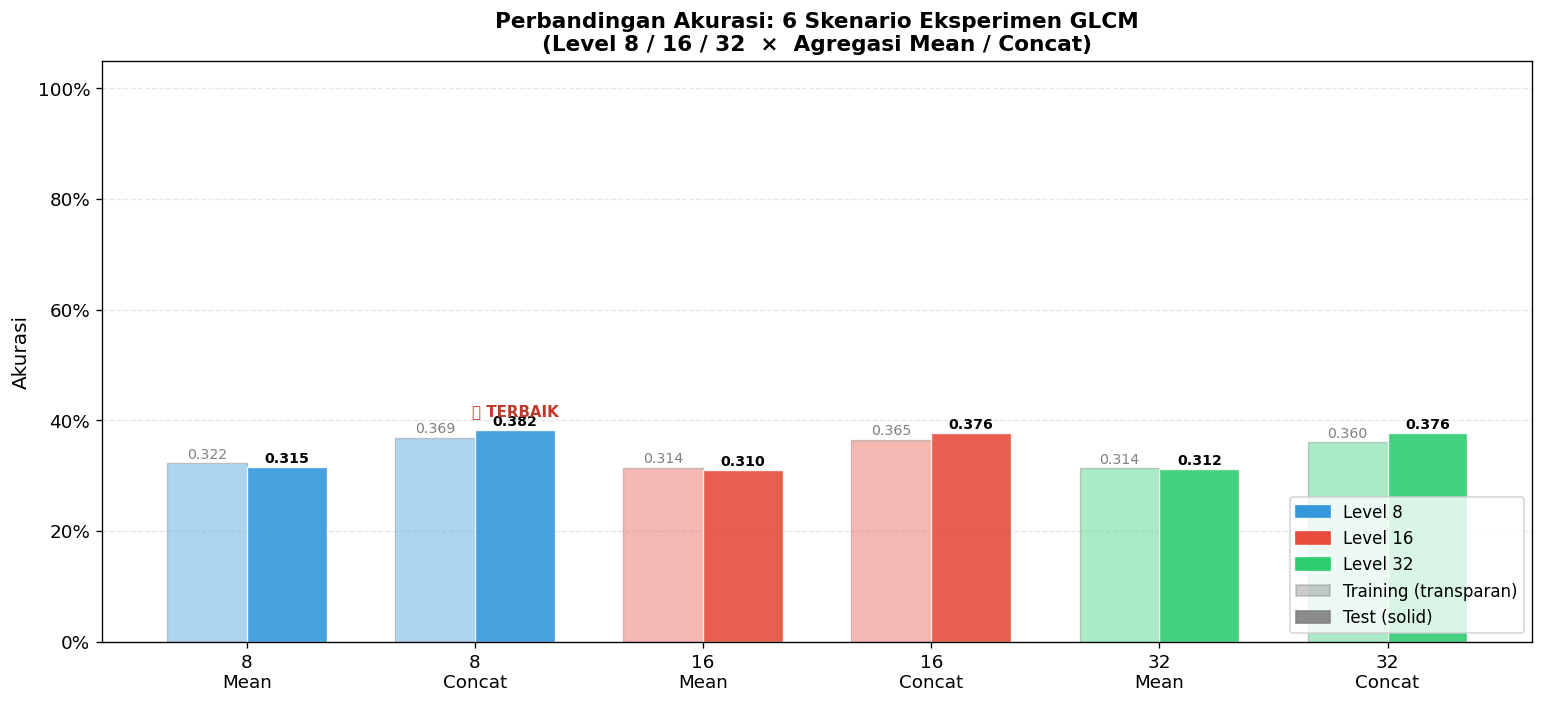

✅ Bar chart perbandingan akurasi disimpan sebagai '05_accuracy_comparison.png'


In [12]:
# ============================================================
#  CELL 4.3 — Bar Chart Perbandingan Akurasi Semua Skenario
# ============================================================

# Siapkan data untuk visualisasi
scenario_keys  = list(results.keys())   # ['8-mean', '8-concat', '16-mean', ...]
acc_train_vals = [results[k]['acc_train'] for k in scenario_keys]
acc_test_vals  = [results[k]['acc_test']  for k in scenario_keys]

x   = np.arange(len(scenario_keys))
w   = 0.35   # Lebar bar

# Warna berdasarkan level kuantisasi
level_colors = {'8': '#3498db', '16': '#e74c3c', '32': '#2ecc71'}
bar_colors   = [level_colors[k.split('-')[0]] for k in scenario_keys]

fig, ax = plt.subplots(figsize=(13, 6))

# Bar untuk akurasi training (transparan)
bars_train = ax.bar(
    x - w/2, acc_train_vals, w,
    label='Akurasi Training',
    color=bar_colors, alpha=0.4, edgecolor='gray', linewidth=0.8
)

# Bar untuk akurasi test (solid)
bars_test = ax.bar(
    x + w/2, acc_test_vals, w,
    label='Akurasi Test',
    color=bar_colors, alpha=0.9, edgecolor='white', linewidth=0.8
)

# Anotasi nilai akurasi di atas bar
for bar in bars_train:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8.5, color='gray'
    )
for bar in bars_test:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8.5, fontweight='bold'
    )

# Tandai skenario terbaik dengan bintang
best_idx = scenario_keys.index(best_key)
ax.text(
    x[best_idx] + w/2,
    results[best_key]['acc_test'] + 0.02,
    '⭐ TERBAIK',
    ha='center', va='bottom', fontsize=9, color='#c0392b', fontweight='bold'
)

# Konfigurasi tampilan
ax.set_xticks(x)
ax.set_xticklabels(
    [k.replace('-', '\n').replace('mean', 'Mean').replace('concat', 'Concat')
     for k in scenario_keys],
    fontsize=11
)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title(
    'Perbandingan Akurasi: 6 Skenario Eksperimen GLCM\n'
    '(Level 8 / 16 / 32  ×  Agregasi Mean / Concat)',
    fontsize=13, fontweight='bold'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Legend khusus untuk level warna
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#3498db', label='Level 8'),
    Patch(color='#e74c3c', label='Level 16'),
    Patch(color='#2ecc71', label='Level 32'),
]
ax.legend(
    handles=legend_patches + [
        Patch(color='gray', alpha=0.4, label='Training (transparan)'),
        Patch(color='gray', alpha=0.9, label='Test (solid)'),
    ],
    fontsize=10, loc='lower right'
)

plt.tight_layout()
plt.savefig('05_accuracy_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Bar chart perbandingan akurasi disimpan sebagai '05_accuracy_comparison.png'")

## 4.4 Visualisasi Distribusi Fitur 2D: PCA dan t-SNE (Analisis 4)

Visualisasi ini menjawab: **"Apakah hubungan fitur GLCM → emosi bersifat linear? Apakah kelas-kelas tersebut bisa dipisahkan secara linear?"**

Kita menggunakan dua metode reduksi dimensi:

### PCA (Principal Component Analysis):
- Metode linear yang memproyeksikan data ke arah variansi terbesar
- Jika kelas terpisah dengan baik di plot PCA → fitur bersifat linear separable
- Jika kelas overlap besar → model linear mungkin tidak cukup

### t-SNE (t-distributed Stochastic Neighbor Embedding):
- Metode **non-linear** yang mempertahankan struktur kedekatan lokal
- Lebih baik dalam memisahkan cluster yang kompleks
- Berguna untuk melihat apakah ada struktur yang tidak bisa ditangkap model linear

### Bedah Sintaks `TSNE()`:
```python
TSNE(
    n_components=2,    # Reduksi ke 2 dimensi (untuk plot 2D)
    perplexity=30,     # Ukuran "lingkungan lokal" yang dipertimbangkan
                       # Nilai umum: 5-50. Data lebih besar → perplexity lebih besar
    n_iter=1000,       # Jumlah iterasi optimasi
    random_state=42    # Reproducibility
)
```

### Library yang Digunakan:
- **`sklearn.decomposition.PCA`**: Reduksi dimensi linear berbasis nilai eigen
- **`sklearn.manifold.TSNE`**: Reduksi dimensi non-linear untuk visualisasi cluster

⏳ Menghitung PCA...
   Variansi yang dijelaskan: PC1=55.46%, PC2=26.77%
   Total: 82.24%

⏳ Menghitung t-SNE (mungkin membutuhkan beberapa menit)...
   ✅ t-SNE selesai!


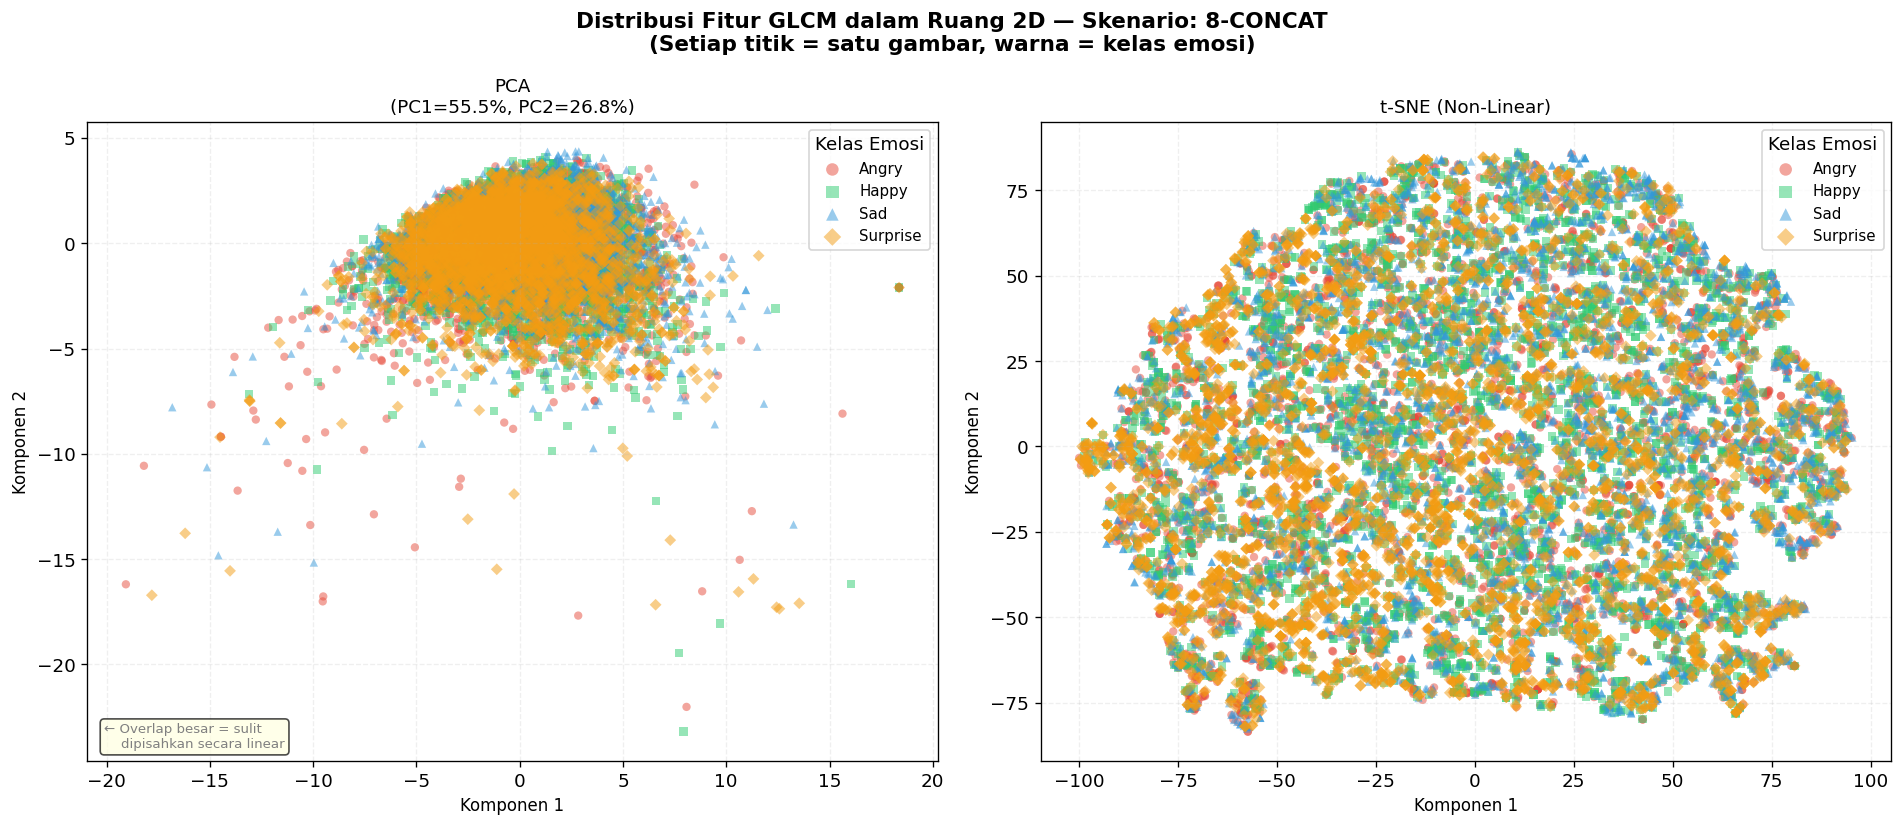

✅ Plot distribusi 2D disimpan sebagai '06_pca_tsne_distribution.png'


In [14]:
# ============================================================
#  CELL 4.4 — PCA & t-SNE: Visualisasi Distribusi Fitur 2D
# ============================================================

# Gunakan fitur dari skenario terbaik
X_best_train = scenarios[best_key]['X_train']
X_best_test  = scenarios[best_key]['X_test']

# Gabungkan train dan test untuk visualisasi yang lebih representatif
X_all = np.vstack([X_best_train, X_best_test])
y_all = np.concatenate([y_train, y_test])

# --- PCA: Reduksi ke 2 komponen utama ---
print("⏳ Menghitung PCA...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all)
explained_var = pca.explained_variance_ratio_
print(f"   Variansi yang dijelaskan: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}")
print(f"   Total: {sum(explained_var):.2%}")

# --- t-SNE: Reduksi non-linear ke 2D ---
print("\n⏳ Menghitung t-SNE (mungkin membutuhkan beberapa menit)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,          # Iterasi optimasi
    learning_rate='auto', # Scikit-learn otomatis mengatur learning rate
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(X_all)
print("   ✅ t-SNE selesai!")

# --- Visualisasi ---
colors_cls  = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
markers_cls = ['o', 's', '^', 'D']   # Lingkaran, kotak, segitiga, berlian

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'Distribusi Fitur GLCM dalam Ruang 2D — Skenario: {best_key.upper()}\n'
    '(Setiap titik = satu gambar, warna = kelas emosi)',
    fontsize=13, fontweight='bold'
)

datasets_2d = [
    (X_pca,  f'PCA\n(PC1={explained_var[0]:.1%}, PC2={explained_var[1]:.1%})', axes[0]),
    (X_tsne, 't-SNE (Non-Linear)',                                              axes[1])
]

for X_2d, title, ax in datasets_2d:
    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, colors_cls, markers_cls)):
        # Ambil indeks sampel yang termasuk kelas ini
        mask = y_all == cls_idx
        ax.scatter(
            X_2d[mask, 0],   # Koordinat sumbu X (komponen pertama)
            X_2d[mask, 1],   # Koordinat sumbu Y (komponen kedua)
            c=color,
            marker=marker,
            label=cls.capitalize(),
            alpha=0.5,
            s=25,            # Ukuran titik
            edgecolors='none'
        )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Komponen 1', fontsize=10)
    ax.set_ylabel('Komponen 2', fontsize=10)
    ax.legend(title='Kelas Emosi', fontsize=9, markerscale=1.5)
    ax.grid(True, alpha=0.2, linestyle='--')

# Tambahkan anotasi interpretasi
axes[0].annotate(
    '← Overlap besar = sulit\n    dipisahkan secara linear',
    xy=(0.02, 0.02), xycoords='axes fraction',
    fontsize=8, color='gray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7)
)

plt.tight_layout()
plt.savefig('06_pca_tsne_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot distribusi 2D disimpan sebagai '06_pca_tsne_distribution.png'")

## 4.5 Error Analysis: Grid Gambar yang Salah Diklasifikasikan (Analisis 5)

Ini adalah salah satu analisis yang paling informatif. Dengan melihat gambar mana yang **salah diprediksi**, kita dapat menjawab:
- Apakah kesalahan masuk akal secara visual? (misalnya: sad mirip dengan angry)
- Apakah gambar yang salah memiliki karakteristik tertentu? (pencahayaan gelap, wajah tidak frontal)
- Apa keterbatasan fitur tekstur GLCM dalam membedakan ekspresi halus?

### Sintaks Penting — `np.where()`:
```python
# np.where(kondisi) mengembalikan tuple berisi array indeks yang memenuhi kondisi
# [0] mengambil array pertama (untuk array 1D)
wrong_indices = np.where(y_test != y_pred_best)[0]
# Contoh: jika y_test[5] != y_pred[5], maka 5 akan masuk dalam wrong_indices
```

🔍 Total kesalahan klasifikasi: 1915 dari 3100 gambar test
   Error rate: 61.77%


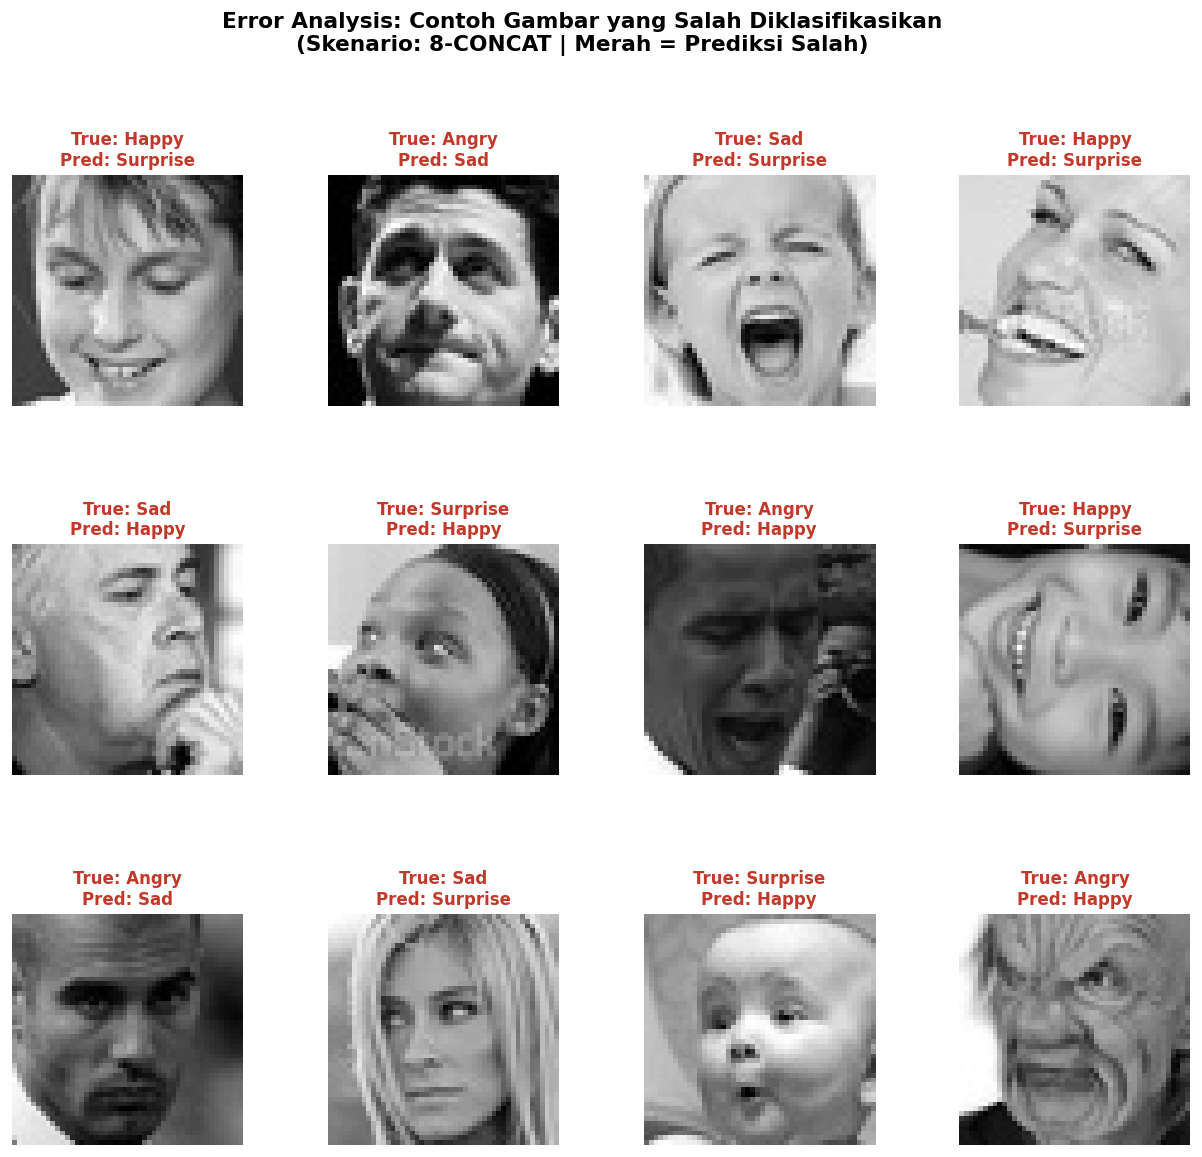

✅ Grid error analysis disimpan sebagai '07_error_analysis.png'


In [15]:
# ============================================================
#  CELL 4.5 — Error Analysis: Gambar yang Salah Diklasifikasikan
# ============================================================

# Temukan semua indeks gambar yang prediksinya SALAH
wrong_indices = np.where(y_test != y_pred_best)[0]

print(f"🔍 Total kesalahan klasifikasi: {len(wrong_indices)} dari {len(y_test)} gambar test")
print(f"   Error rate: {len(wrong_indices)/len(y_test):.2%}")

# Ambil maksimal 12 contoh kesalahan secara acak
rng = np.random.default_rng(RANDOM_STATE)
n_show = min(12, len(wrong_indices))
sampled_wrong = rng.choice(wrong_indices, size=n_show, replace=False)

# --- Buat Grid Visualisasi Kesalahan ---
n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3.2, n_rows * 3.5),
    gridspec_kw={'hspace': 0.6, 'wspace': 0.3}
)
axes_flat = axes.flatten()   # Ubah grid 2D → list 1D agar mudah diiterasi

fig.suptitle(
    f'Error Analysis: Contoh Gambar yang Salah Diklasifikasikan\n'
    f'(Skenario: {best_key.upper()} | Merah = Prediksi Salah)',
    fontsize=13, fontweight='bold', y=1.01
)

for plot_idx, test_idx in enumerate(sampled_wrong):
    ax = axes_flat[plot_idx]

    # Ambil gambar dari test_raw
    img = test_raw[test_idx]

    # Decode label dari integer ke string
    true_label = le.inverse_transform([y_test[test_idx]])[0].capitalize()
    pred_label = le.inverse_transform([y_pred_best[test_idx]])[0].capitalize()

    ax.imshow(img, cmap='gray')

    # Judul berwarna: merah untuk prediksi salah
    ax.set_title(
        f'True: {true_label}\nPred: {pred_label}',
        fontsize=10,
        color='#c0392b',    # Merah untuk menandai kesalahan
        fontweight='bold'
    )
    ax.axis('off')

    # Tambahkan border merah pada gambar yang salah
    for spine in ax.spines.values():
        spine.set_edgecolor('#e74c3c')
        spine.set_linewidth(2)
        spine.set_visible(True)

# Sembunyikan subplot yang tidak terpakai
for idx in range(n_show, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.savefig('07_error_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Grid error analysis disimpan sebagai '07_error_analysis.png'")

---
# BAGIAN 5 — Ringkasan Hasil & Panduan Analisis Laporan

## 5.1 Tabel Rekap Semua Eksperimen

In [16]:
# ============================================================
#  CELL 5.1 — Tabel Rekap Semua Eksperimen
# ============================================================

print("=" * 70)
print("  📋 REKAP HASIL EKSPERIMEN KLASIFIKASI EMOSI WAJAH")
print("=" * 70)
print(f"  {'Skenario':<20} {'Level':>7} {'Agregasi':>10} {'Dim Fitur':>11} {'Akurasi Test':>14}")
print("-" * 70)

for key in scenario_keys:
    level, agg = key.split('-')
    n_feat = scenarios[key]['n_feat']
    acc    = results[key]['acc_test']
    marker = " ⭐" if key == best_key else ""
    print(f"  {key:<20} {level:>7} {agg.capitalize():>10} {n_feat:>11} {acc:>13.4f}{marker}")

print("-" * 70)
print(f"  TERBAIK: {best_key.upper()} dengan Akurasi = {best_acc:.4f} ({best_acc:.2%})")
print("=" * 70)

print("""
📝 PANDUAN UNTUK ANALISIS LAPORAN:

1. APAKAH GLCM CUKUP MEMBEDAKAN EMOSI?
   → Lihat Confusion Matrix (file: 04_confusion_matrix.png)
     Perhatikan nilai diagonal. Jika akurasi keseluruhan < 50% atau banyak
     cell off-diagonal besar, GLCM mungkin tidak cukup representatif.

2. EMOSI MANA YANG PALING SULIT DIPREDIKSI?
   → Lihat kolom Recall di Classification Report dan baris di Confusion Matrix
     Kelas dengan Recall terendah = paling sering salah terklasifikasi.

3. PERAN KUANTISASI LEVEL (8 vs 16 vs 32)?
   → Lihat Bar Chart (file: 05_accuracy_comparison.png)
     Level lebih tinggi = representasi lebih detail, tapi bisa overfit/underfitting.

4. APAKAH HUBUNGAN FITUR → EMOSI LINEAR?
   → Lihat plot t-SNE (file: 06_pca_tsne_distribution.png)
     Jika kelas overlap besar bahkan di t-SNE, fitur GLCM tidak cukup diskriminatif.
     Jika kelas terpisah di t-SNE tapi tidak di PCA, hubungannya NON-LINEAR.

5. KETERBATASAN MODEL (Error Analysis)?
   → Lihat grid gambar salah (file: 07_error_analysis.png)
     Identifikasi pola: apakah gambar gelap, ekspresi halus, wajah miring?
     Ini adalah evidence konkret untuk bab Diskusi di laporan.
""")

  📋 REKAP HASIL EKSPERIMEN KLASIFIKASI EMOSI WAJAH
  Skenario               Level   Agregasi   Dim Fitur   Akurasi Test
----------------------------------------------------------------------
  8-mean                     8       Mean           4        0.3152
  8-concat                   8     Concat          16        0.3823 ⭐
  16-mean                   16       Mean           4        0.3100
  16-concat                 16     Concat          16        0.3765
  32-mean                   32       Mean           4        0.3116
  32-concat                 32     Concat          16        0.3765
----------------------------------------------------------------------
  TERBAIK: 8-CONCAT dengan Akurasi = 0.3823 (38.23%)

📝 PANDUAN UNTUK ANALISIS LAPORAN:

1. APAKAH GLCM CUKUP MEMBEDAKAN EMOSI?
   → Lihat Confusion Matrix (file: 04_confusion_matrix.png)
     Perhatikan nilai diagonal. Jika akurasi keseluruhan < 50% atau banyak
     cell off-diagonal besar, GLCM mungkin tidak cukup representa

---

## Kesimpulan Notebook

Notebook ini telah mendemonstrasikan pipeline lengkap:

```
Load Dataset  →  Grayscale + Normalize  →  Kuantisasi GLCM  →  Ekstraksi Fitur
      ↓
StandardScaler  →  LogisticRegression  →  Evaluasi (6 Skenario)
      ↓
Classification Report + Confusion Matrix + PCA/t-SNE + Error Analysis
```

### File Output yang Dihasilkan:
| File | Konten |
|---|---|
| `01_before_after_preprocessing.png` | Grid Before/After normalisasi per kelas |
| `02_glcm_heatmap.png` | Heatmap matriks GLCM untuk 4 sudut |
| `03_glcm_feature_comparison.png` | Bar chart perbandingan fitur antar kelas |
| `04_confusion_matrix.png` | Confusion matrix absolut & ternormalisasi |
| `05_accuracy_comparison.png` | Perbandingan akurasi 6 skenario |
| `06_pca_tsne_distribution.png` | Distribusi fitur 2D (PCA & t-SNE) |
| `07_error_analysis.png` | Grid gambar yang salah diklasifikasikan |

---
*Notebook dibuat untuk tugas klasifikasi emosi wajah menggunakan GLCM + Logistic Regression.*  
*Dataset: Subset FER2013 | Scikit-learn ≥ 1.5 | Scikit-image ≥ 0.20*